In [16]:
import os
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [18]:
dataset_path = kagglehub.dataset_download("emmarex/plantdisease")

data_dir = None
for folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, folder)
    if os.path.isdir(full_path):
        data_dir = full_path
        break

print("Dataset:", data_dir)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset: /kaggle/input/plantdisease/PlantVillage


In [19]:
temp_dataset = datasets.ImageFolder(root=data_dir)
class_names = temp_dataset.classes

print("Classes:", len(class_names))
print(class_names[:10])

Classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [21]:
dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

In [22]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [23]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [25]:
epochs = 5

for epoch in range(epochs):

    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = 100 * correct / total

    print(f"Epoch {epoch+1}")
    print(f"Loss: {total_loss:.4f}")
    print(f"Accuracy: {acc:.2f}%\n")

Epoch 1
Loss: 398.9124
Accuracy: 77.22%

Epoch 2
Loss: 176.9729
Accuracy: 89.29%

Epoch 3
Loss: 139.8926
Accuracy: 90.95%

Epoch 4
Loss: 122.2763
Accuracy: 91.94%

Epoch 5
Loss: 111.5230
Accuracy: 92.32%



In [26]:
model.eval()

y_true = []
y_pred = []

misclassified_images = []
misclassified_true = []
misclassified_pred = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

        # store mistakes for analysis
        for i in range(len(labels)):
            if preds[i].item() != labels[i].item():
                misclassified_images.append(images[i].cpu())
                misclassified_true.append(labels[i].item())
                misclassified_pred.append(preds[i].item())

In [27]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.96      0.97       139
                     Pepper__bell___healthy       0.98      0.99      0.98       227
                      Potato___Early_blight       0.95      0.99      0.97       155
                       Potato___Late_blight       0.89      0.92      0.91       137
                           Potato___healthy       0.93      0.96      0.94        26
                      Tomato_Bacterial_spot       0.90      0.99      0.94       312
                        Tomato_Early_blight       0.85      0.69      0.76       150
                         Tomato_Late_blight       0.93      0.86      0.90       263
                           Tomato_Leaf_Mold       0.91      0.88      0.89       154
                  Tomato_Septoria_leaf_spot       0.87      0.92      0.89       251
Tomato_Spider_mites_Two_spotted_spider_mite       0.85      0.96

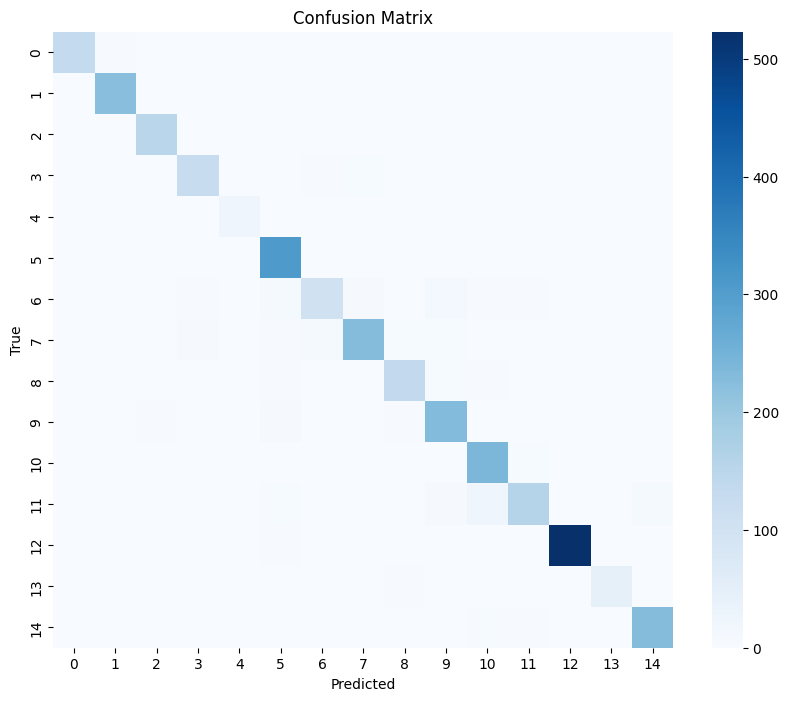

In [28]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

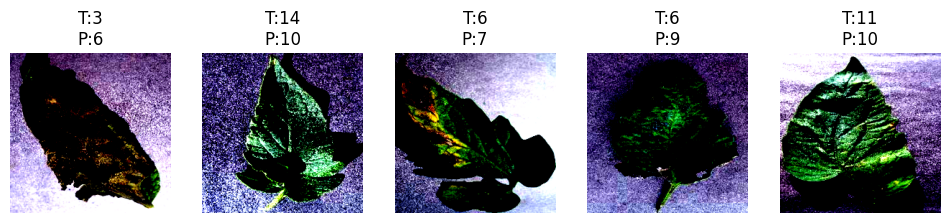

In [29]:
def show_examples(images, true_labels, pred_labels, n=5):

    plt.figure(figsize=(12,5))

    for i in range(n):

        img = images[i].permute(1,2,0)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"T:{true_labels[i]}\nP:{pred_labels[i]}")
        plt.axis("off")

    plt.show()

show_examples(
    misclassified_images,
    misclassified_true,
    misclassified_pred,
    n=5
)

In [30]:
print("Total test samples:", len(y_true))
print("Misclassified samples:", len(misclassified_true))

error_rate = len(misclassified_true) / len(y_true)
print("Error rate:", round(error_rate * 100, 2), "%")

Total test samples: 3097
Misclassified samples: 232
Error rate: 7.49 %
